In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / "data" / "retail.duckdb"
IMAGES = PROJECT_ROOT / "images"

con = duckdb.connect(str(DB_PATH), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).fetchdf()

print(q("SHOW TABLES"))

           name
0  dim_customer
1      dim_date
2   dim_product
3    fact_sales


In [6]:
q("""
SELECT
    COUNT(DISTINCT invoice_no) AS antal_ordrar,
    COUNT(DISTINCT customer_id) AS antal_kunder,
    COUNT(DISTINCT product_key) AS antal_produkter,
    ROUND(SUM(revenue), 0) AS total_intakt,
    ROUND(SUM(revenue) / COUNT(DISTINCT invoice_no), 2) AS snitt_ordervarde,
    ROUND(100.0 * SUM(CASE WHEN is_cancellation THEN 1 ELSE 0 END) / COUNT(*), 2) AS makulering_pct
FROM fact_sales;
""")

,antal_ordrar,antal_kunder,antal_produkter,total_intakt,snitt_ordervarde,makulering_pct
0,23796,4371,3828,9748131.0,409.65,1.73


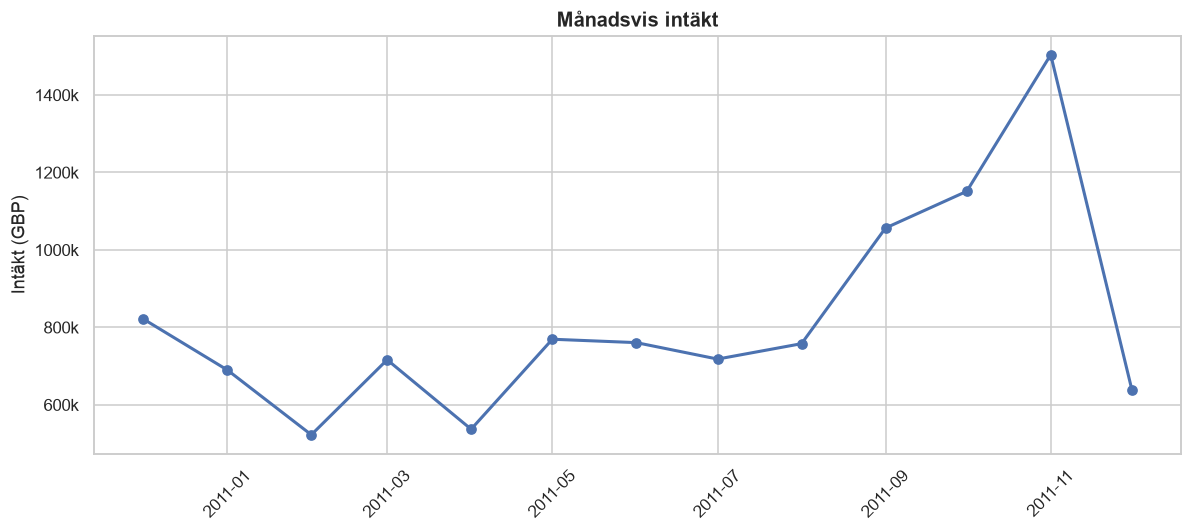

,manad,intakt,ordrar,aktiva_kunder
0,2010-12-01,821453.0,1559,885
1,2011-01-01,689812.0,1086,741
2,2011-02-01,522546.0,1100,758
3,2011-03-01,716215.0,1454,974
4,2011-04-01,536968.0,1246,856
5,2011-05-01,769297.0,1681,1056
6,2011-06-01,760547.0,1533,991
7,2011-07-01,718076.0,1475,949
8,2011-08-01,757841.0,1361,935
9,2011-09-01,1056435.0,1837,1266


In [7]:
monthly = q("""
SELECT
    d.month_start AS manad,
    ROUND(SUM(f.revenue), 0) AS intakt,
    COUNT(DISTINCT f.invoice_no) AS ordrar,
    COUNT(DISTINCT f.customer_id) AS aktiva_kunder
FROM fact_sales f
JOIN dim_date d ON f.date_key = d.date_key
WHERE NOT f.is_cancellation
GROUP BY d.month_start
ORDER BY d.month_start;
""")

fig, ax = plt.subplots()
ax.plot(monthly["manad"], monthly["intakt"], marker="o", linewidth=2)
ax.set_title("Månadsvis intäkt", fontsize=13, weight="bold")
ax.set_ylabel("Intäkt (GBP)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}k")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES / "monthly_revenue.png", bbox_inches="tight")
plt.show()

monthly

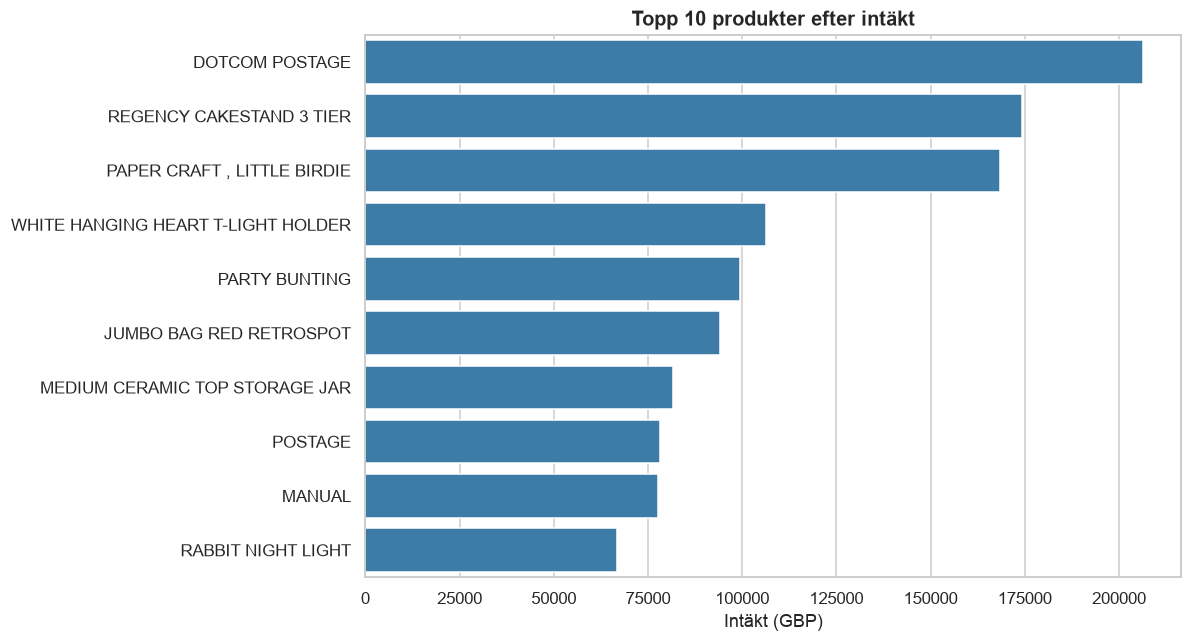

,produkt,antal_salda,intakt,unika_kunder
0,DOTCOM POSTAGE,706.0,206249.0,1
1,REGENCY CAKESTAND 3 TIER,13851.0,174157.0,881
2,"PAPER CRAFT , LITTLE BIRDIE",80995.0,168470.0,1
3,WHITE HANGING HEART T-LIGHT HOLDER,37933.0,106415.0,856
4,PARTY BUNTING,18283.0,99445.0,708
5,JUMBO BAG RED RETROSPOT,48371.0,94160.0,635
6,MEDIUM CERAMIC TOP STORAGE JAR,78033.0,81701.0,138
7,POSTAGE,3150.0,78102.0,331
8,MANUAL,6985.0,77753.0,197
9,RABBIT NIGHT LIGHT,30739.0,66870.0,450


In [8]:
top_products = q("""
SELECT
    p.description AS produkt,
    SUM(f.quantity) AS antal_salda,
    ROUND(SUM(f.revenue), 0) AS intakt,
    COUNT(DISTINCT f.customer_id) AS unika_kunder
FROM fact_sales f
JOIN dim_product p ON f.product_key = p.product_key
WHERE NOT f.is_cancellation
GROUP BY p.description
ORDER BY intakt DESC
LIMIT 10;
""")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_products, y="produkt", x="intakt", ax=ax, color="#2c7fb8")
ax.set_title("Topp 10 produkter efter intäkt", fontsize=13, weight="bold")
ax.set_xlabel("Intäkt (GBP)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGES / "top_products.png", bbox_inches="tight")
plt.show()

top_products

In [9]:
q("""
SELECT
    country AS land,
    COUNT(DISTINCT customer_id) AS kunder,
    COUNT(DISTINCT invoice_no) AS ordrar,
    ROUND(SUM(revenue), 0) AS intakt,
    ROUND(100.0 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS andel_av_total_pct
FROM fact_sales
WHERE NOT is_cancellation
GROUP BY country
ORDER BY intakt DESC
LIMIT 15;
""")

,land,kunder,ordrar,intakt,andel_av_total_pct
0,United Kingdom,3920,18019,9001744.0,84.59
1,Netherlands,9,94,285446.0,2.68
2,EIRE,3,288,283141.0,2.66
3,Germany,94,457,228678.0,2.15
4,France,87,392,209625.0,1.97
5,Australia,9,57,138454.0,1.30
6,Spain,30,90,61559.0,0.58
7,Switzerland,21,54,57068.0,0.54
8,Belgium,25,98,41196.0,0.39
9,Sweden,8,36,38368.0,0.36


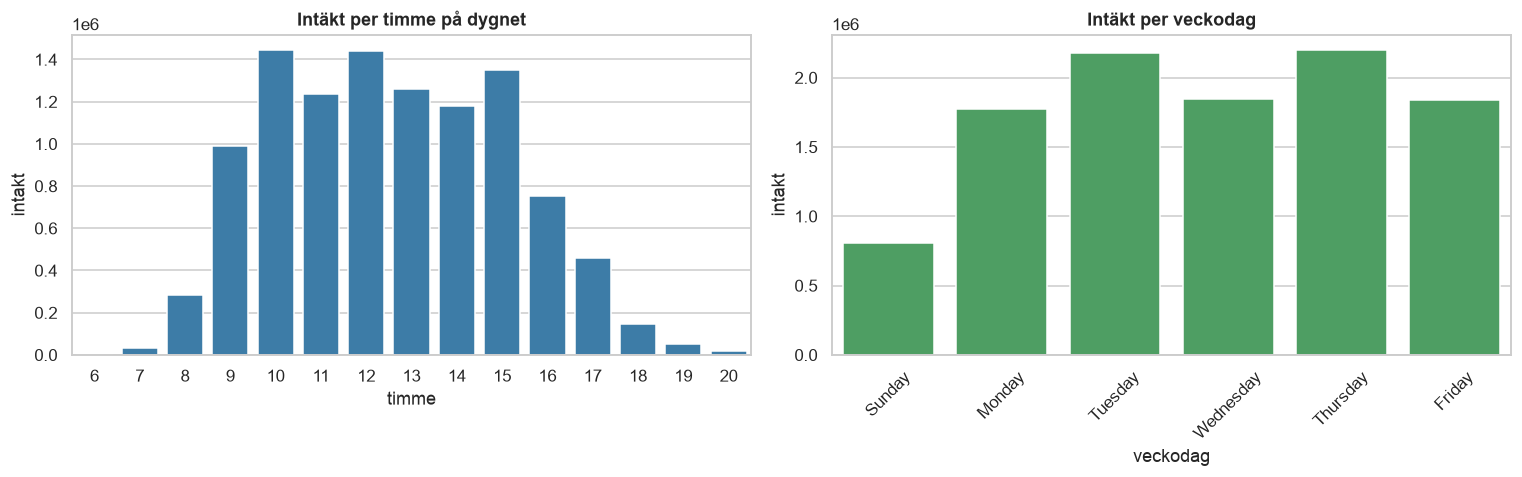

In [10]:
by_hour = q("""
SELECT
    EXTRACT(hour FROM invoice_date) AS timme,
    COUNT(DISTINCT invoice_no) AS ordrar,
    ROUND(SUM(revenue), 0) AS intakt
FROM fact_sales
WHERE NOT is_cancellation
GROUP BY timme
ORDER BY timme;
""")

by_day = q("""
SELECT
    d.day_name AS veckodag,
    d.day_of_week,
    ROUND(SUM(f.revenue), 0) AS intakt
FROM fact_sales f
JOIN dim_date d ON f.date_key = d.date_key
WHERE NOT f.is_cancellation
GROUP BY d.day_name, d.day_of_week
ORDER BY d.day_of_week;
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=by_hour, x="timme", y="intakt", ax=axes[0], color="#2c7fb8")
axes[0].set_title("Intäkt per timme på dygnet", weight="bold")
sns.barplot(data=by_day, x="veckodag", y="intakt", ax=axes[1], color="#41ab5d")
axes[1].set_title("Intäkt per veckodag", weight="bold")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(IMAGES / "time_patterns.png", bbox_inches="tight")
plt.show()

In [11]:
q("""
WITH customer_value AS (
    SELECT
        customer_id,
        country,
        COUNT(DISTINCT invoice_no) AS antal_ordrar,
        ROUND(SUM(revenue), 2) AS livstidsvarde,
        ROUND(AVG(revenue), 2) AS snitt_radvarde,
        MIN(CAST(invoice_date AS DATE)) AS forsta_kop,
        MAX(CAST(invoice_date AS DATE)) AS senaste_kop
    FROM fact_sales
    WHERE customer_id IS NOT NULL
      AND NOT is_cancellation
    GROUP BY customer_id, country
)
SELECT
    RANK() OVER (ORDER BY livstidsvarde DESC) AS rang,
    customer_id,
    country,
    antal_ordrar,
    livstidsvarde,
    NTILE(10) OVER (ORDER BY livstidsvarde DESC) AS decil,
    ROUND(100.0 * livstidsvarde / SUM(livstidsvarde) OVER (), 3) AS andel_av_total_pct
FROM customer_value
ORDER BY livstidsvarde DESC
LIMIT 20;
""")

,rang,customer_id,country,antal_ordrar,livstidsvarde,decil,andel_av_total_pct
0,1,14646,Netherlands,73,280206.02,1,3.153
1,2,18102,United Kingdom,60,259657.30,1,2.922
2,3,17450,United Kingdom,46,194390.79,1,2.187
3,4,16446,United Kingdom,2,168472.50,1,1.896
4,5,14911,EIRE,201,143711.17,1,1.617
5,6,12415,Australia,21,124914.53,1,1.406
6,7,14156,EIRE,55,117210.08,1,1.319
7,8,17511,United Kingdom,31,91062.38,1,1.025
8,9,16029,United Kingdom,63,80850.84,1,0.910
9,10,12346,United Kingdom,1,77183.60,1,0.868


In [12]:
mom = q("""
WITH monthly AS (
    SELECT
        d.month_start AS manad,
        SUM(f.revenue) AS intakt
    FROM fact_sales f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE NOT f.is_cancellation
    GROUP BY d.month_start
)
SELECT
    manad,
    ROUND(intakt, 0) AS intakt,
    ROUND(LAG(intakt) OVER (ORDER BY manad), 0) AS foregaende_manad,
    ROUND(intakt - LAG(intakt) OVER (ORDER BY manad), 0) AS forandring,
    ROUND(100.0 * (intakt - LAG(intakt) OVER (ORDER BY manad)) / NULLIF(LAG(intakt) OVER (ORDER BY manad), 0), 1) AS tillvaxt_pct,
    ROUND(SUM(intakt) OVER (ORDER BY manad ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 0) AS ackumulerat
FROM monthly
ORDER BY manad;
""")

mom

,manad,intakt,foregaende_manad,forandring,tillvaxt_pct,ackumulerat
0,2010-12-01,821453.0,NaN,NaN,NaN,821453.0
1,2011-01-01,689812.0,821453.0,-131641.0,-16.0,1511264.0
2,2011-02-01,522546.0,689812.0,-167266.0,-24.2,2033810.0
3,2011-03-01,716215.0,522546.0,193670.0,37.1,2750025.0
4,2011-04-01,536968.0,716215.0,-179247.0,-25.0,3286994.0
5,2011-05-01,769297.0,536968.0,232328.0,43.3,4056290.0
6,2011-06-01,760547.0,769297.0,-8750.0,-1.1,4816837.0
7,2011-07-01,718076.0,760547.0,-42471.0,-5.6,5534913.0
8,2011-08-01,757841.0,718076.0,39765.0,5.5,6292755.0
9,2011-09-01,1056435.0,757841.0,298594.0,39.4,7349190.0


In [13]:
q("""
WITH product_by_country AS (
    SELECT
        f.country,
        p.description AS produkt,
        SUM(f.revenue) AS intakt
    FROM fact_sales f
    JOIN dim_product p ON f.product_key = p.product_key
    WHERE NOT f.is_cancellation
    GROUP BY f.country, p.description
),
ranked AS (
    SELECT
        country,
        produkt,
        ROUND(intakt, 0) AS intakt,
        RANK() OVER (PARTITION BY country ORDER BY intakt DESC) AS rang_i_land
    FROM product_by_country
),
top_countries AS (
    SELECT country
    FROM fact_sales
    WHERE NOT is_cancellation
    GROUP BY country
    ORDER BY SUM(revenue) DESC
    LIMIT 8
)
SELECT r.*
FROM ranked r
JOIN top_countries t USING (country)
WHERE r.rang_i_land <= 3
ORDER BY r.country, r.rang_i_land;
""")

,country,produkt,intakt,rang_i_land
0,Australia,RABBIT NIGHT LIGHT,3376.0,1
1,Australia,SET OF 6 SPICE TINS PANTRY DESIGN,2082.0,2
2,Australia,RED TOADSTOOL LED NIGHT LIGHT,1987.0,3
3,EIRE,REGENCY CAKESTAND 3 TIER,7793.0,1
4,EIRE,MANUAL,7050.0,2
5,EIRE,CARRIAGE,5240.0,3
6,France,POSTAGE,15454.0,1
7,France,MANUAL,9492.0,2
8,France,RABBIT NIGHT LIGHT,7277.0,3
9,Germany,POSTAGE,21001.0,1


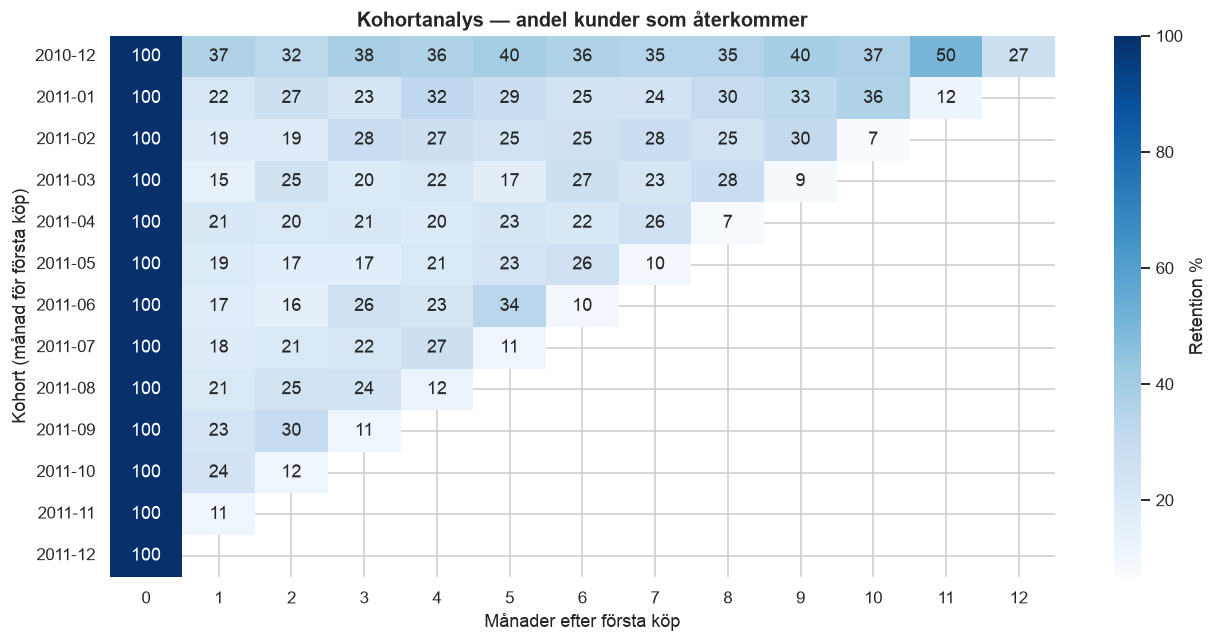

In [14]:
cohort = q("""
WITH first_purchase AS (
    SELECT
        customer_id,
        DATE_TRUNC('month', MIN(invoice_date)) AS cohort_month
    FROM fact_sales
    WHERE customer_id IS NOT NULL AND NOT is_cancellation
    GROUP BY customer_id
),
customer_activity AS (
    SELECT DISTINCT
        f.customer_id,
        fp.cohort_month,
        DATE_TRUNC('month', f.invoice_date) AS activity_month
    FROM fact_sales f
    JOIN first_purchase fp USING (customer_id)
    WHERE NOT f.is_cancellation
),
cohort_matrix AS (
    SELECT
        cohort_month,
        DATE_DIFF('month', cohort_month, activity_month) AS manad_index,
        COUNT(DISTINCT customer_id) AS aktiva_kunder
    FROM customer_activity
    GROUP BY cohort_month, manad_index
),
cohort_size AS (
    SELECT
        cohort_month,
        aktiva_kunder AS kohortstorlek
    FROM cohort_matrix
    WHERE manad_index = 0
)
SELECT
    cm.cohort_month,
    cs.kohortstorlek,
    cm.manad_index,
    cm.aktiva_kunder,
    ROUND(100.0 * cm.aktiva_kunder / cs.kohortstorlek, 1) AS retention_pct
FROM cohort_matrix cm
JOIN cohort_size cs USING (cohort_month)
ORDER BY cm.cohort_month, cm.manad_index;
""")

pivot = cohort.pivot(index="cohort_month", columns="manad_index", values="retention_pct")
pivot.index = pivot.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Retention %"}, ax=ax)
ax.set_title("Kohortanalys — andel kunder som återkommer", fontsize=13, weight="bold")
ax.set_xlabel("Månader efter första köp")
ax.set_ylabel("Kohort (månad för första köp)")
plt.tight_layout()
plt.savefig(IMAGES / "cohort_retention.png", bbox_inches="tight")
plt.show()

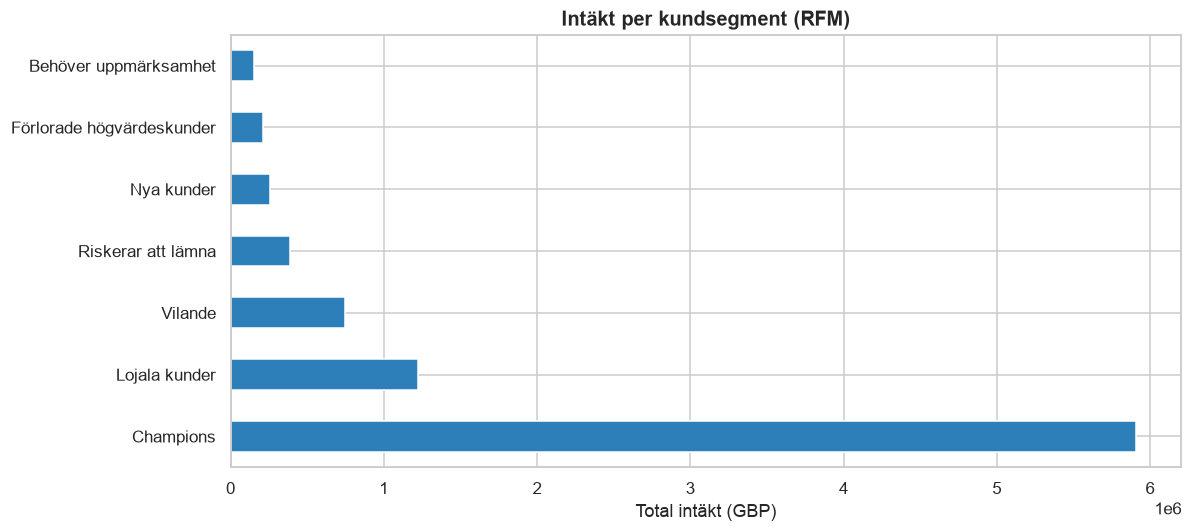

,antal_kunder,snitt_recency,snitt_frequency,total_intakt,andel_av_intakt_pct
segment,,,,,
Champions,1176,13.8,9.7,5909195.2,66.5
Lojala kunder,823,37.2,3.6,1220976.6,13.7
Vilande,1442,201.5,1.5,748466.7,8.4
Riskerar att lämna,211,129.7,5.5,389055.2,4.4
Nya kunder,255,17.9,1.1,255655.5,2.9
Förlorade högvärdeskunder,83,185.7,1.4,210169.7,2.4
Behöver uppmärksamhet,348,54.6,1.2,153690.0,1.7


In [15]:
rfm = q("""
WITH snapshot AS (
    SELECT MAX(invoice_date) + INTERVAL 1 DAY AS snapshot_date
    FROM fact_sales
),
customer_rfm AS (
    SELECT
        f.customer_id,
        DATE_DIFF('day', MAX(CAST(f.invoice_date AS DATE)), CAST((SELECT snapshot_date FROM snapshot) AS DATE)) AS recency,
        COUNT(DISTINCT f.invoice_no) AS frequency,
        ROUND(SUM(f.revenue), 2) AS monetary
    FROM fact_sales f
    WHERE f.customer_id IS NOT NULL
      AND NOT f.is_cancellation
    GROUP BY f.customer_id
    HAVING SUM(f.revenue) > 0
),
scored AS (
    SELECT
        *,
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM customer_rfm
)
SELECT
    customer_id,
    recency,
    frequency,
    monetary,
    r_score, f_score, m_score,
    CAST(r_score AS VARCHAR) || CAST(f_score AS VARCHAR) || CAST(m_score AS VARCHAR) AS rfm_kod,
    CASE
        WHEN r_score >= 4 AND f_score >= 4 THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 3 THEN 'Lojala kunder'
        WHEN r_score >= 4 AND f_score <= 2 THEN 'Nya kunder'
        WHEN r_score <= 2 AND f_score >= 4 THEN 'Riskerar att lämna'
        WHEN r_score <= 2 AND f_score <= 2 AND m_score >= 4 THEN 'Förlorade högvärdeskunder'
        WHEN r_score <= 2 THEN 'Vilande'
        ELSE 'Behöver uppmärksamhet'
    END AS segment
FROM scored
ORDER BY monetary DESC;
""")

segment_summary = rfm.groupby("segment").agg(
    antal_kunder=("customer_id", "count"),
    snitt_recency=("recency", "mean"),
    snitt_frequency=("frequency", "mean"),
    total_intakt=("monetary", "sum"),
).round(1).sort_values("total_intakt", ascending=False)

segment_summary["andel_av_intakt_pct"] = (
    100 * segment_summary["total_intakt"] / segment_summary["total_intakt"].sum()
).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
segment_summary["total_intakt"].plot(kind="barh", ax=ax, color="#2c7fb8")
ax.set_title("Intäkt per kundsegment (RFM)", fontsize=13, weight="bold")
ax.set_xlabel("Total intäkt (GBP)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGES / "rfm_segments.png", bbox_inches="tight")
plt.show()

segment_summary

In [16]:
q("""
WITH sales AS (
    SELECT
        product_key,
        SUM(CASE WHEN NOT is_cancellation THEN quantity ELSE 0 END) AS salda,
        SUM(CASE WHEN is_cancellation THEN ABS(quantity) ELSE 0 END) AS returnerade,
        SUM(CASE WHEN NOT is_cancellation THEN revenue ELSE 0 END) AS brutto_intakt
    FROM fact_sales
    GROUP BY product_key
)
SELECT
    p.description AS produkt,
    s.salda,
    s.returnerade,
    ROUND(100.0 * s.returnerade / NULLIF(s.salda, 0), 1) AS returgrad_pct,
    ROUND(s.brutto_intakt, 0) AS brutto_intakt
FROM sales s
JOIN dim_product p ON s.product_key = p.product_key
WHERE s.salda > 500
ORDER BY returgrad_pct DESC
LIMIT 15;
""")

,produkt,salda,returnerade,returgrad_pct,brutto_intakt
0,"PAPER CRAFT , LITTLE BIRDIE",80995.0,80995.0,100.0,168470.0
1,ROTATING SILVER ANGELS T-LIGHT HLDR,9461.0,9376.0,99.1,26426.0
2,MEDIUM CERAMIC TOP STORAGE JAR,78033.0,74494.0,95.5,81701.0
3,PANTRY CHOPPING BOARD,1154.0,946.0,82.0,5869.0
4,IVORY CHANDELIER T-LIGHT HOLDER,657.0,432.0,65.8,1395.0
5,FLOWERS CHANDELIER T-LIGHT HOLDER,963.0,579.0,60.1,2898.0
6,MANUAL,6985.0,4066.0,58.2,77753.0
7,BEADED CHANDELIER T-LIGHT HOLDER,773.0,433.0,56.0,1769.0
8,TEA TIME PARTY BUNTING,2578.0,1424.0,55.2,12926.0
9,HERB MARKER BASIL,3423.0,1527.0,44.6,2153.0


In [17]:
q("""
WITH order_dates AS (
    SELECT DISTINCT
        customer_id,
        CAST(invoice_date AS DATE) AS orderdatum
    FROM fact_sales
    WHERE customer_id IS NOT NULL AND NOT is_cancellation
),
gaps AS (
    SELECT
        customer_id,
        orderdatum,
        LAG(orderdatum) OVER (PARTITION BY customer_id ORDER BY orderdatum) AS foregaende_order,
        DATE_DIFF('day', LAG(orderdatum) OVER (PARTITION BY customer_id ORDER BY orderdatum), orderdatum) AS dagar_mellan
    FROM order_dates
)
SELECT
    customer_id,
    COUNT(*) + 1 AS antal_ordrar,
    ROUND(AVG(dagar_mellan), 1) AS snitt_dagar_mellan_kop,
    MIN(dagar_mellan) AS kortaste_intervall,
    MAX(dagar_mellan) AS langsta_intervall
FROM gaps
WHERE dagar_mellan IS NOT NULL
GROUP BY customer_id
HAVING COUNT(*) >= 4
ORDER BY snitt_dagar_mellan_kop ASC
LIMIT 20;
""")

,customer_id,antal_ordrar,snitt_dagar_mellan_kop,kortaste_intervall,langsta_intervall
0,14911,132,2.8,1,17
1,12748,113,3.3,1,30
2,17841,112,3.4,1,16
3,15311,90,4.2,1,21
4,14606,89,4.2,1,13
5,12971,71,5.3,1,16
6,13089,66,5.6,1,20
7,14096,17,6.1,2,10
8,16790,6,6.8,1,13
9,14527,54,6.9,1,16


In [18]:
con.close()
con = duckdb.connect(str(DB_PATH))  # nu utan read_only

con.execute("""
CREATE OR REPLACE VIEW v_monthly_kpi AS
SELECT
    d.month_start AS manad,
    COUNT(DISTINCT f.invoice_no) AS ordrar,
    COUNT(DISTINCT f.customer_id) AS aktiva_kunder,
    SUM(f.revenue) AS intakt,
    SUM(f.revenue) / COUNT(DISTINCT f.invoice_no) AS snitt_ordervarde
FROM fact_sales f
JOIN dim_date d ON f.date_key = d.date_key
WHERE NOT f.is_cancellation
GROUP BY d.month_start;
""")

con.execute("""
CREATE OR REPLACE VIEW v_customer_rfm AS
WITH snapshot AS (
    SELECT MAX(invoice_date) + INTERVAL 1 DAY AS snapshot_date FROM fact_sales
),
base AS (
    SELECT
        customer_id,
        DATE_DIFF('day', MAX(CAST(invoice_date AS DATE)), CAST((SELECT snapshot_date FROM snapshot) AS DATE)) AS recency,
        COUNT(DISTINCT invoice_no) AS frequency,
        SUM(revenue) AS monetary
    FROM fact_sales
    WHERE customer_id IS NOT NULL AND NOT is_cancellation
    GROUP BY customer_id
    HAVING SUM(revenue) > 0
)
SELECT
    *,
    NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
    NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
    NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
FROM base;
""")

con.execute("""
CREATE OR REPLACE VIEW v_product_performance AS
SELECT
    p.stock_code,
    p.description,
    SUM(CASE WHEN NOT f.is_cancellation THEN f.quantity ELSE 0 END) AS antal_salda,
    SUM(CASE WHEN f.is_cancellation THEN ABS(f.quantity) ELSE 0 END) AS antal_returer,
    SUM(CASE WHEN NOT f.is_cancellation THEN f.revenue ELSE 0 END) AS intakt,
    COUNT(DISTINCT f.customer_id) AS unika_kunder
FROM fact_sales f
JOIN dim_product p ON f.product_key = p.product_key
GROUP BY p.stock_code, p.description;
""")

print(con.execute("SELECT * FROM v_monthly_kpi ORDER BY manad LIMIT 5").fetchdf())

       manad  ordrar  aktiva_kunder      intakt  snitt_ordervarde
0 2010-12-01    1559            885  821452.730        526.910026
1 2011-01-01    1086            741  689811.610        635.185645
2 2011-02-01    1100            758  522545.560        475.041418
3 2011-03-01    1454            974  716215.260        492.582710
4 2011-04-01    1246            856  536968.491        430.953845


In [20]:
con.close()